# Word2Vec-SVC Classifier


word2vec is an NLP algorithm that uses a neural network to learn associations between words.
It is used to convert words tokenised by the spaCy library from the text dataset into word vectors
for an SVM. The word vectors for each set of tokens are averaged to generate a sentence
vector that is fed into the classification model.

In [3]:
# pip install gensim
!pip install spacy

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-0.4.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached confection-0.1.5-py3-none-any.whl.metadata (19 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 797.5 kB/s eta 0:00:00a 0:00:01
Using cached catalogue-2.0.10-py3-none-any.whl (17 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 602.6 kB/s eta 0:00:00a 0:00:01
Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl (29 kB)
Using cached spacy_loggers-1.0.5-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.4/634.4 kB 984.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━

In [4]:
import gensim.downloader as api

word_vect = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [6]:
pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.7.0/en_core_web_md-3.7.0-py3-none-any.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 820.1 kB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.0/779.0 kB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: blis
    Found existing installation: blis 1.2.1
    Uninstalling blis-1.2.1:
      Successfully uninstalled blis-1.2.1
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.4
    Uninstalling thinc-8.3.4:
      Successfully uninstalled thinc-8.3.4
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.5
    Uninstalling spacy-3.8.5:
      Successfully uninstalled spacy-3.8.5
Note: you may need to restart the kernel to use updated packages.


In [7]:
import spacy

nlp = spacy.load('en_core_web_md')

/opt/homebrew/lib/python3.10/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_md' (3.7.0) was trained with spaCy v3.7.0 and may not be 100% compatible with the current version (3.8.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [8]:
# tokenises a sentence using spacy library
def spacy_tokenizer(text):
    doc = nlp(text)

    # lemmatise tokens
    tokens = [word.lemma_.strip() for word in doc]

    return tokens

In [9]:
import numpy as np

# takes a tokenized sentence input from spacy and takes average of all word vectors
def sentence_vect(tokens):
    # word2vec output size (300 for word2vec-google-news-300)
    size = word_vect.vector_size

    # create a vector of zeroes
    sent_vect = np.zeros(size)

    # get average of all word vectors of each token
    counter = 0
    for word in tokens:
        if word in word_vect:
            sent_vect += word_vect[word]
            counter += 1

    if counter == 0:
        return None

    sent_vect = sent_vect / counter
    return sent_vect

In [10]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [11]:
df = pd.read_csv('/Users/nourbenammar/Desktop/Esprit_project/cleaned_learning_outcomes.csv')

# removes all punctuations and change to lower case
df['text'] = df['text'].str.replace(r'[^\w\s]+', '', regex=True)
df['text'] = df['text'].str.lower()

# Blooms taxonomy categories
categories = ['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create']

In [12]:
# add a row of tokenised text
df['Tokens'] = df['text'].apply(spacy_tokenizer)

In [13]:
# create sentence vectors by taking average of token vectors
df['Vectors'] = df['Tokens'].apply(sentence_vect)

# drop all null values after tokenizing as some cells may not have relevant data
df = df.dropna(axis=0, subset=['Vectors'])

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2)

## Model Building

In [15]:
from sklearn.svm import SVC

# model based on Support Vector Machine (non-probabilistic classifier)
model = SVC(kernel='linear', gamma='auto', degree=3)

# Fit sentence vectors to labels
model.fit(list(train.Vectors), train.label)

# Generate blooms label on test set
labels = model.predict(list(test.Vectors))

              precision    recall  f1-score   support

           0       0.64      0.49      0.56       180
           1       0.76      0.83      0.79      1016
           2       0.72      0.77      0.74      1016
           3       0.58      0.51      0.54       469
           4       0.76      0.67      0.71       502
           5       0.72      0.70      0.71       572

    accuracy                           0.72      3755
   macro avg       0.70      0.66      0.68      3755
weighted avg       0.71      0.72      0.71      3755

Accuracy: 0.7163781624500666


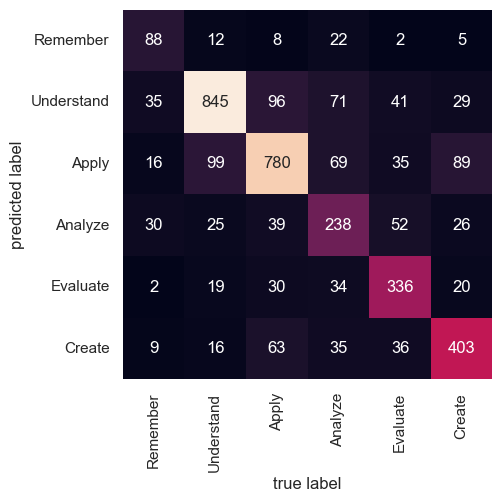

In [ ]:
# model report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

mat = confusion_matrix(test.label, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False
            , xticklabels=categories
            , yticklabels=categories)

plt.xlabel('true label')
plt.ylabel('predicted label')

print(classification_report(test.label, labels))

acc = accuracy_score(test.label, labels)
print("Accuracy:", acc)